In [ ]:
# Use MNIST Fashion Dataset and create a classifier to classify fashion clothing into categories.

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split

c:\Users\Asus\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.0) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [2]:
# Load CSV files
train_data = pd.read_csv("C:/Users/Asus/Downloads/archive (4)/fashion-mnist_train.csv")
test_data = pd.read_csv("C:/Users/Asus/Downloads/archive (4)/fashion-mnist_test.csv")

print(train_data.shape)
print(test_data.shape)

(60000, 785)
(10000, 785)


In [3]:
# Separate Features and Labels

X = train_data.drop("label", axis=1).values.astype('float32')
y = train_data["label"].values.astype('int32')

X_test = test_data.drop("label", axis=1).values.astype('float32')
y_test = test_data["label"].values.astype('int32')

In [4]:
# Reshape into 28x28x1
X = X.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [5]:
# Scale pixel values between 0 and 1
X = X / 255.0
X_test = X_test / 255.0

In [6]:
# One-hot encoding
y = to_categorical(y, 10)
y_test = to_categorical(y_test, 10)


In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_val.shape)

(48000, 28, 28, 1)
(12000, 28, 28, 1)


In [9]:
model = Sequential()

# First Convolution Layer
model.add(Conv2D(
    filters=32,
    kernel_size=(3,3),
    activation='relu',
    input_shape=(28,28,1)
))

# Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Layer
model.add(Conv2D(
    filters=64,
    kernel_size=(3,3),
    activation='relu'
))

# Second Pooling
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation='relu'))

# Dropout
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(10, activation='softmax'))

In [10]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val)
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.7657 - loss: 0.6475 - val_accuracy: 0.8547 - val_loss: 0.4034
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8460 - loss: 0.4288 - val_accuracy: 0.8741 - val_loss: 0.3416
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8652 - loss: 0.3777 - val_accuracy: 0.8825 - val_loss: 0.3202
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8782 - loss: 0.3418 - val_accuracy: 0.8897 - val_loss: 0.2925
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8873 - loss: 0.3187 - val_accuracy: 0.8955 - val_loss: 0.2830
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8940 - loss: 0.2980 - val_accuracy: 0.8990 - val_loss: 0.2700
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8976 - loss: 0.2817 - val_accuracy: 0.8976 - val_loss: 0.2776
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9040 - loss: 0.2622 - val_accu

In [13]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9089 - loss: 0.2503
Test Accuracy: 0.9089000225067139


In [14]:
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)

actual_classes = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [15]:
fashion_labels = [
    "T-shirt/Top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

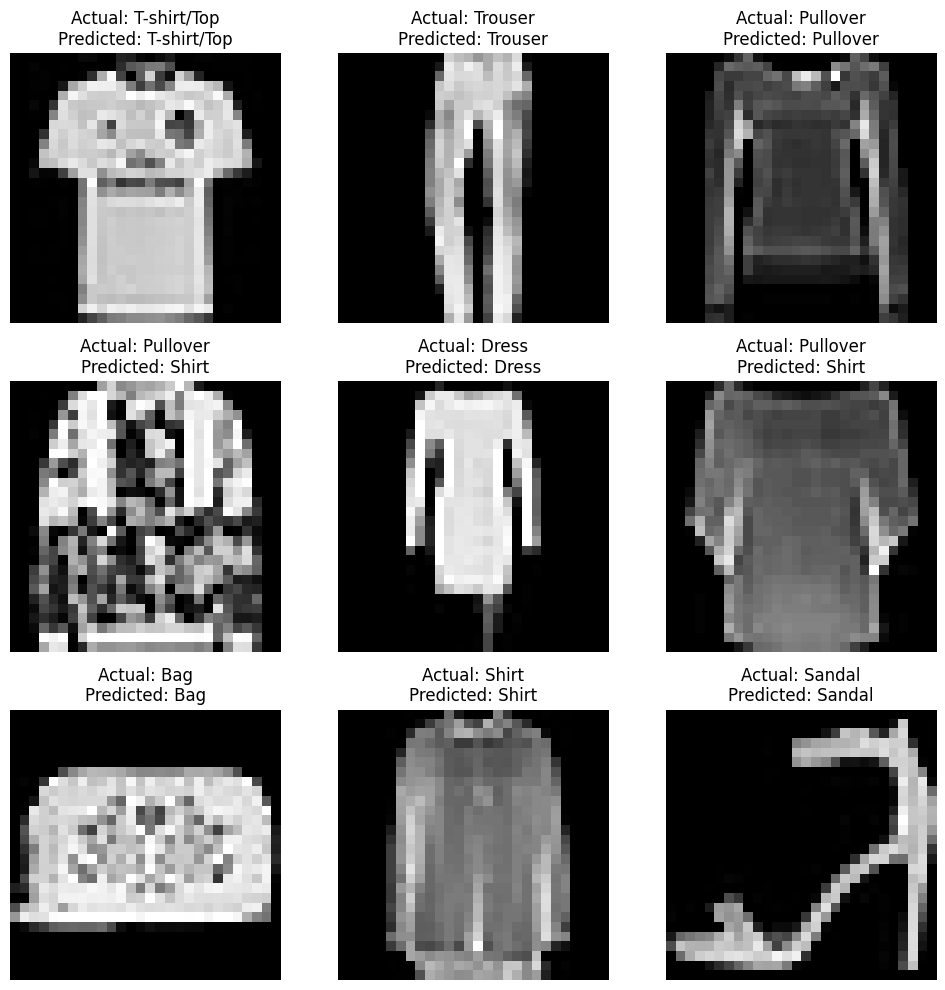

In [16]:
plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)

    plt.imshow(X_test[i].reshape(28,28), cmap='gray')

    plt.title(
        f"Actual: {fashion_labels[actual_classes[i]]}\n"
        f"Predicted: {fashion_labels[predicted_classes[i]]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()